In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Dataset_new.csv")

years = sorted(df['year'].unique())

results_list = []
yearly_summary_list = []

feature_cols = [
    'Rndrng_Prvdr_Type',
    'Rndrng_Prvdr_State_Abrvtn',
    'Rndrng_Prvdr_Mdcr_Prtcptg_Ind',
    'log_Tot_Benes',
    'log_Tot_Srvcs',
    'Bene_Avg_Age',
    'Bene_Avg_Risk_Scre',
]

target_col = 'Tot_Mdcr_Pymt_Amt_log'

for i in range(len(years) - 2):
    train_year_1 = years[i]
    train_year_2 = years[i + 1]
    test_year = years[i + 2]

    df_y0 = df[df['year'] == train_year_1].copy()
    df_y1 = df[df['year'] == train_year_2].copy()
    df_y2 = df[df['year'] == test_year].copy()

    # keep only providers present in all 3 years
    common_npi = (
        set(df_y0['Rndrng_NPI'])
        .intersection(set(df_y1['Rndrng_NPI']))
        .intersection(set(df_y2['Rndrng_NPI']))
    )

    train_df_1 = df_y0[df_y0['Rndrng_NPI'].isin(common_npi)].copy()
    train_df_2 = df_y1[df_y1['Rndrng_NPI'].isin(common_npi)].copy()
    test_df = df_y2[df_y2['Rndrng_NPI'].isin(common_npi)].copy()

    # combine first two years for training
    train_df = pd.concat([train_df_1, train_df_2], ignore_index=True)

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    # one-hot encode
    X_train = pd.get_dummies(X_train, drop_first=True)
    X_test = pd.get_dummies(X_test, drop_first=True)

    # match test columns to train columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    temp = test_df[['Rndrng_NPI', 'year']].copy()
    temp['actual'] = y_test.values
    temp['predicted'] = y_pred

    # convert back to dollars if target was log1p
    temp['actual_dollars'] = np.expm1(temp['actual'])
    temp['predicted_dollars'] = np.expm1(temp['predicted'])

    temp['train_year_1'] = train_year_1
    temp['train_year_2'] = train_year_2

    results_list.append(temp)

    yearly_summary_list.append({
        'train_year_1': train_year_1,
        'train_year_2': train_year_2,
        'test_year': test_year,
        'sum_actual_dollars': temp['actual_dollars'].sum(),
        'sum_predicted_dollars': temp['predicted_dollars'].sum(),
        'sum_ratio_dollars': temp['predicted_dollars'].sum() / temp['actual_dollars'].sum(),
        'log_sum_ratio_dollars': np.log(temp['predicted_dollars'].sum() / temp['actual_dollars'].sum()),
        'yearly_metric': (temp['predicted'] - temp['actual']).sum() / temp['Rndrng_NPI'].nunique()
    })

results = pd.concat(results_list, ignore_index=True)
yearly_summary = pd.DataFrame(yearly_summary_list)

print(yearly_summary)

   train_year_1  train_year_2  test_year  sum_actual_dollars  \
0          2013          2014       2015        8.843160e+10   
1          2014          2015       2016        9.053195e+10   
2          2015          2016       2017        9.250430e+10   
3          2016          2017       2018        9.552386e+10   
4          2017          2018       2019        9.966805e+10   
5          2018          2019       2020        9.148665e+10   
6          2019          2020       2021        1.021718e+11   
7          2020          2021       2022        9.956312e+10   
8          2021          2022       2023        1.036415e+11   

   sum_predicted_dollars  sum_ratio_dollars  log_sum_ratio_dollars  \
0           8.851103e+10           1.000898               0.000898   
1           8.880202e+10           0.980891              -0.019293   
2           8.804378e+10           0.951780              -0.049421   
3           8.946216e+10           0.936543              -0.065560   
4        

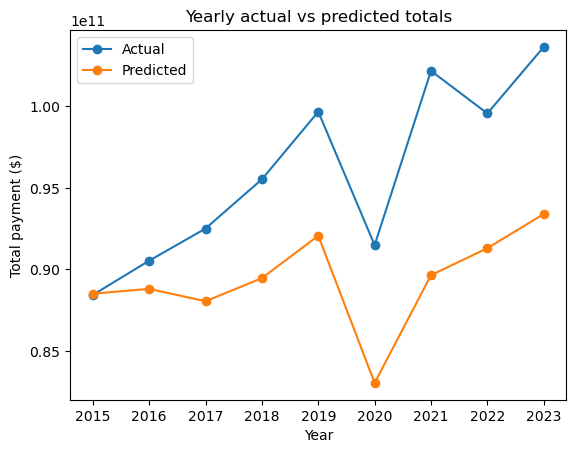

In [7]:
import matplotlib.pyplot as plt

yearly_compare = (
    results.groupby('year')
    .agg(
        actual=('actual_dollars', 'sum'),
        predicted=('predicted_dollars', 'sum')
    )
    .reset_index()
)

plt.plot(yearly_compare['year'], yearly_compare['actual'], marker='o', label='Actual')
plt.plot(yearly_compare['year'], yearly_compare['predicted'], marker='o', label='Predicted')
plt.xlabel('Year')
plt.ylabel('Total payment ($)')
plt.title('Yearly actual vs predicted totals')
plt.legend()
plt.show()

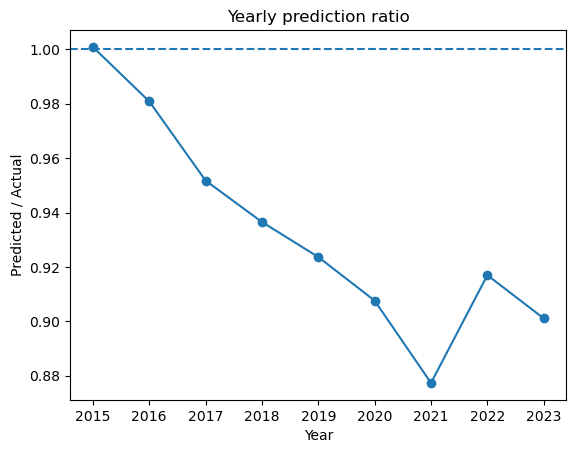

In [8]:
yearly_compare['ratio'] = yearly_compare['predicted'] / yearly_compare['actual']

plt.plot(yearly_compare['year'], yearly_compare['ratio'], marker='o')
plt.axhline(1.0, linestyle='--')
plt.xlabel('Year')
plt.ylabel('Predicted / Actual')
plt.title('Yearly prediction ratio')
plt.show()

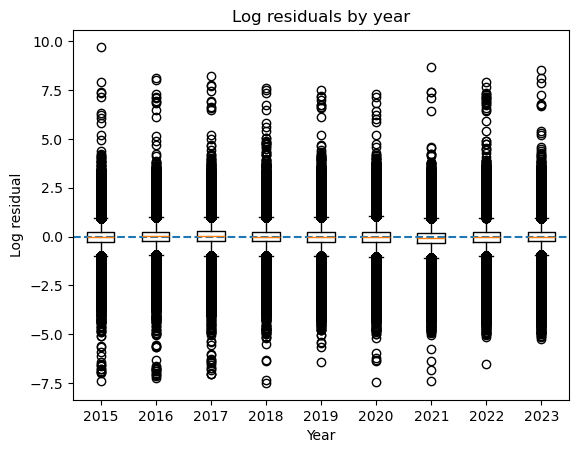

In [13]:
results['log_residual'] = results['predicted'] - results['actual']

plt.boxplot(
    [results.loc[results['year'] == y, 'log_residual'] for y in sorted(results['year'].unique())],
    tick_labels=sorted(results['year'].unique())
)
plt.axhline(0.0, linestyle='--')
plt.xlabel('Year')
plt.ylabel('Log residual')
plt.title('Log residuals by year')
plt.show()
